# XGBoost Price Forecasting Model
## Training Notebook for OGDC Stock Prediction

This notebook trains an XGBoost Regressor using technical indicators to predict the next day's closing price.

In [18]:
# Install required packages
!pip install xgboost pandas numpy ta matplotlib scikit-learn

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=98286aa9d4922fc7a1cd257f67c2335d18d62a2a1e3bcc685141cb0313531440
  Stored in directory: /root/.cache/pip/wheels/5c/a1/5f/c6b85a7d9452057be4ce68a8e45d77ba34234a6d46581777c6
Successfully built ta


In [19]:
import pandas as pd
import numpy as np
import xgboost as xgb
import io
from google.colab import files
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

## Step 1: Load Data

In [20]:
# --- Load Data (With Upload Button) ---
import pandas as pd
import io
from google.colab import files

print("Please upload 'ogdc_data.csv'...")

# 1. Upload the File
uploaded = files.upload()
filename = next(iter(uploaded))

# 2. Read into Pandas
df = pd.read_csv(io.BytesIO(uploaded[filename]))

# 3. Clean & Sort
df.columns = df.columns.str.strip().str.lower() # Standardize column names
df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f"✅ Loaded {len(df)} rows")
print(f"Date range: {df['date'].min()} to {df['date'].max()}")
df.head()

Please upload 'ogdc_data.csv'...


Saving ogdc_data_updated.csv to ogdc_data_updated (1).csv
✅ Loaded 1223 rows
Date range: 2021-03-01 00:00:00 to 2026-02-06 00:00:00


,id,ticker,date,open,high,low,close,volume
0,235,OGDC,2021-03-01,105.15,105.45,103.40,104.48,993856
1,236,OGDC,2021-03-02,104.00,107.00,103.71,105.40,1627498
2,237,OGDC,2021-03-03,105.99,106.70,104.05,106.22,849105
3,238,OGDC,2021-03-04,103.50,106.00,103.50,104.28,1610733
4,239,OGDC,2021-03-05,106.40,108.40,104.25,107.10,1858659


## Step 2: Feature Engineering - Technical Indicators

In [21]:
# 1. Feature Engineering (Manual Math - No 'ta' library needed)
# This matches exactly what backtest.py does
df = df.sort_values('date').reset_index(drop=True)

# RSI (14)
delta = df['close'].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))

# SMA & EMA
df['SMA_20'] = df['close'].rolling(window=20).mean()
df['SMA_50'] = df['close'].rolling(window=50).mean()
df['EMA_12'] = df['close'].ewm(span=12, adjust=False).mean()

# Drop NaN values created by indicators
df = df.dropna().reset_index(drop=True)

## Step 3: Prepare Features & Target

In [22]:
# 2. Define Features & Target (THE CRITICAL FIX)
# Features: We add 'close' because current price is the best predictor of next price
feature_cols = ['RSI', 'SMA_20', 'SMA_50', 'EMA_12', 'close']
X = df[feature_cols].values

# Target: We shift(-1) to predict TOMORROW's price
y = df['close'].shift(-1).dropna()
X = X[:-1] # Remove the last row because it has no tomorrow

print(f"Features: {feature_cols}")
print(f"X Shape: {X.shape}, y Shape: {y.shape}")

Features: ['RSI', 'SMA_20', 'SMA_50', 'EMA_12', 'close']
X Shape: (1173, 5), y Shape: (1173,)


## Step 4: Train/Test Split

In [23]:
# 3. Train/Test Split
# We use a time-series split (no shuffling)
split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

## Step 5: Train XGBoost Model

In [24]:
# 4. Train XGBoost
model = xgb.XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=10,
    random_state=42,
    objective='reg:squarederror'
)
print("🔄 Training...")
model.fit(X_train, y_train)

🔄 Training...


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=10,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

## Step 6: Evaluate Model

In [25]:
# 5. Evaluate
preds = model.predict(X_test)
mape = np.mean(np.abs((y_test - preds) / y_test)) * 100
print(f"\n✅ New Accuracy: {100 - mape:.2f}%")


✅ New Accuracy: 87.93%


## Step 7: Visualize Predictions

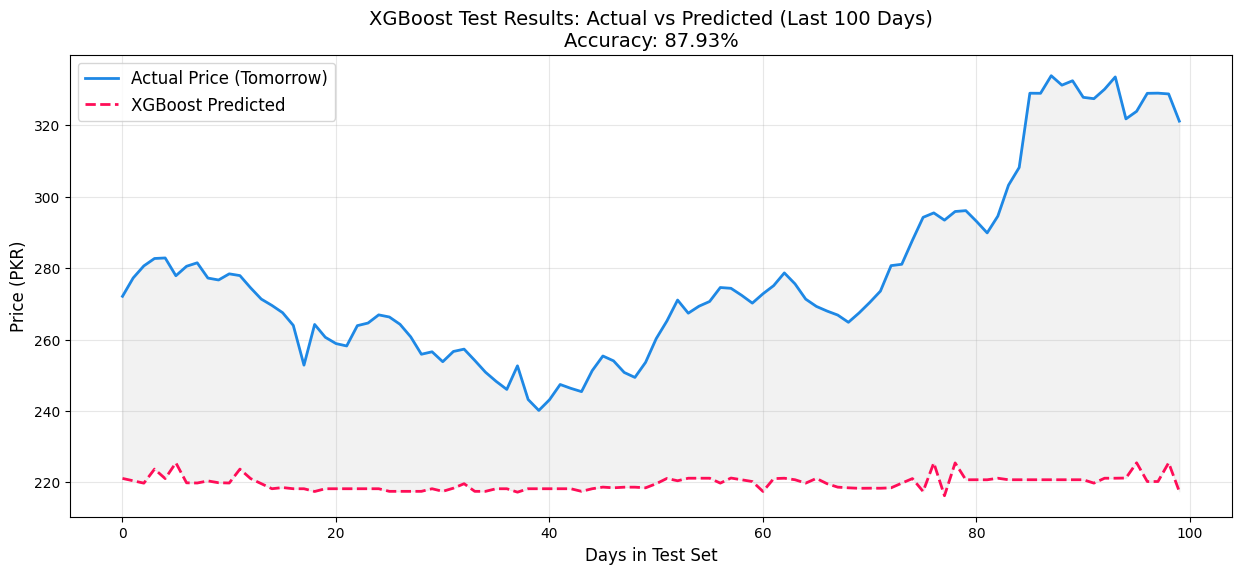

In [26]:
# --- VISUALIZE PREDICTIONS ---
plt.figure(figsize=(15, 6))

# Plot only the last 100 days for clarity
# We use .values to ensure matplotlib handles it correctly whether it's Series or Array
plt.plot(y_test[-100:].values, label='Actual Price (Tomorrow)', color='#1e88e5', linewidth=2)
plt.plot(preds[-100:], label='XGBoost Predicted', color='#ff0d57', linestyle='--', linewidth=2)

plt.title(f'XGBoost Test Results: Actual vs Predicted (Last 100 Days)\nAccuracy: {100-mape:.2f}%', fontsize=14)
plt.xlabel('Days in Test Set', fontsize=12)
plt.ylabel('Price (PKR)', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

# Highlight the specific zone where they overlap
plt.fill_between(range(100), y_test[-100:].values, preds[-100:], color='gray', alpha=0.1)

plt.show()

## Step 8: Save Model

In [27]:
# Save as JSON for Flask integration
model.save_model('xgb_model.json')
print("\n✅ Model saved as 'xgb_model.json'")
print("📥 Download this file and place it in your Flask project directory.")


✅ Model saved as 'xgb_model.json'
📥 Download this file and place it in your Flask project directory.


## Step 9: Test Prediction (Single Example)

In [28]:
# Test prediction with latest data
latest_features = X_test[-1:]
prediction = model.predict(latest_features)

print(f"\n🔮 Sample Prediction:")
print(f"Features: RSI={latest_features[0][0]:.2f}, SMA_20={latest_features[0][1]:.2f}, SMA_50={latest_features[0][2]:.2f}, EMA_12={latest_features[0][3]:.2f}")
print(f"Actual Price:    Rs. {y_test.iloc[-1]:.2f}")
print(f"Predicted Price: Rs. {prediction[0]:.2f}")
print(f"Difference:      Rs. {abs(y_test.iloc[-1] - prediction[0]):.2f}")


🔮 Sample Prediction:
Features: RSI=67.20, SMA_20=319.61, SMA_50=292.48, EMA_12=325.08
Actual Price:    Rs. 321.18
Predicted Price: Rs. 217.46
Difference:      Rs. 103.72
